# Day 13 — Ecosystems
### #30DayChartChallenge | April 2026

**Biodiversity at Risk.** A dot matrix showing threatened species (CR + EN + VU) across 15 countries, broken down by mammals, birds, fishes, and plants. Dot size scales to count. PhyloPic silhouettes identify each category. Madagascar leads with 2,894 threatened plant species alone.

**Data:** World Bank / IUCN Red List of Threatened Species (2022)  
**Silhouettes:** [PhyloPic](https://www.phylopic.org/)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(tidyr)
library(showtext)
library(sysfonts)
library(rphylopic)
library(ggimage)
library(countrycode)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb

Warning message:
"package 'rphylopic' was built under R version 4.5.3"
You are using rphylopic v.1.6.0. Please remember to credit PhyloPic contributors (hint: `get_attribution()`) and cite rphylopic in your work (hint: `citation("rphylopic")`).

Warning message:
"package 'ggimage' was built under R version 4.5.3"

Attaching package: 'ggimage'


The following object is masked from 'package:rphylopic':

    geom_phylopic


Warning message:
"package 'countrycode' was built under R version 4.5.3"


In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 12, repr.plot.height = 13, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------
# Source: World Bank API (EN.MAM.THRD.NO, EN.BIR.THRD.NO, EN.FSH.THRD.NO, EN.HPT.THRD.NO)
# Original source: IUCN Red List of Threatened Species (2022 assessment)

df <- read.csv("../../data/day_13/iucn_threatened_species.csv",
               stringsAsFactors = FALSE)

df$country <- factor(df$country, levels = rev(df$country[order(df$total)]))

# Flags
df$iso2 <- tolower(countrycode(df$country, "country.name", "iso2c"))
df$flag_url <- paste0("https://flagcdn.com/w80/", df$iso2, ".png")

df_long <- df %>%
  select(country, iso3, total, flag_url, mammals, birds, fishes, plants) %>%
  pivot_longer(cols = c(mammals, birds, fishes, plants),
               names_to = "category", values_to = "count")

cat_order <- c("mammals", "birds", "fishes", "plants")
cat_labels <- c("Mammals", "Birds", "Fishes", "Plants")
df_long$category <- factor(df_long$category, levels = cat_order, labels = cat_labels)

head(df)

,country,iso3,mammals,birds,fishes,plants,total,iso2,flag_url
,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,Madagascar,MDG,133,37,127,2894,3191,mg,https://flagcdn.com/w80/mg.png
2,Ecuador,ECU,49,86,99,2029,2263,ec,https://flagcdn.com/w80/ec.png
3,Brazil,BRA,97,155,360,1346,1958,br,https://flagcdn.com/w80/br.png
4,Mexico,MEX,97,68,308,1426,1899,mx,https://flagcdn.com/w80/mx.png
5,Indonesia,IDN,212,161,366,977,1716,id,https://flagcdn.com/w80/id.png
6,Malaysia,MYS,80,67,183,1317,1647,my,https://flagcdn.com/w80/my.png


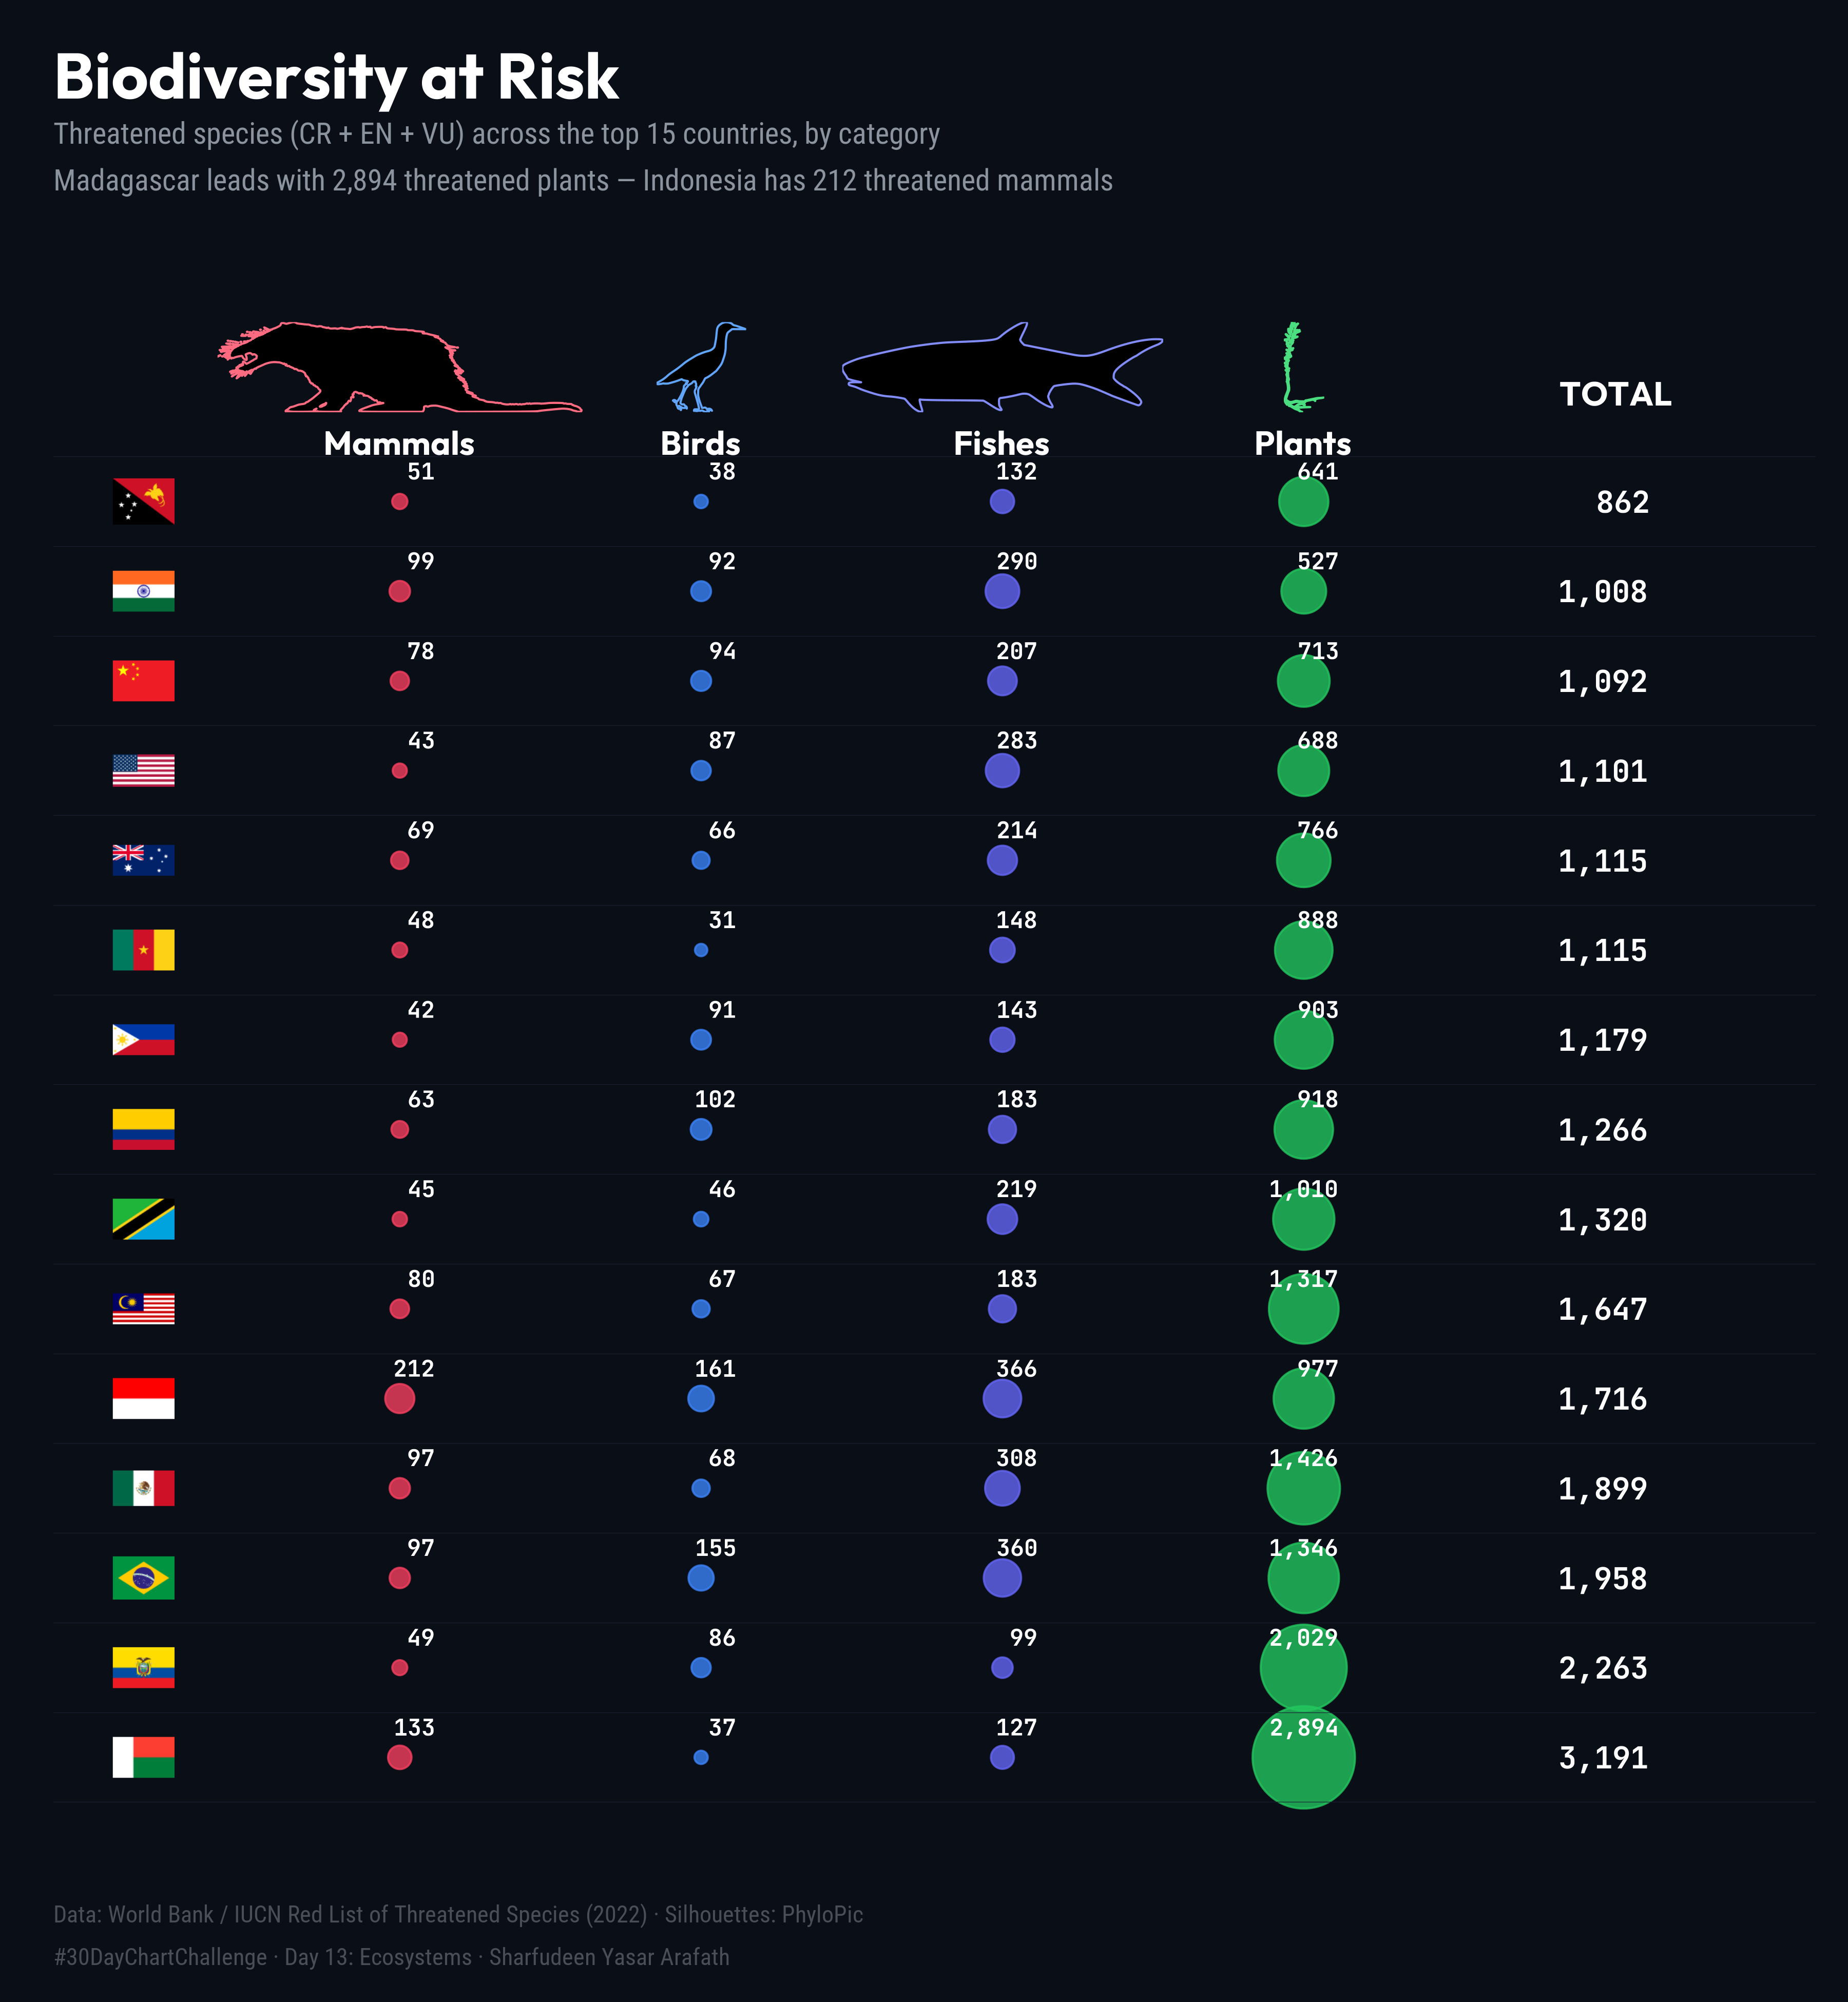

In [4]:
# — build the plot ------------------------------------------------------------

uuids <- c(
  Mammals = "f4b6df56-f216-4a4c-9940-4105da8b462e",
  Birds   = "6add767f-6ff7-486e-b4d5-ddce60fb8409",
  Fishes  = "7360374f-8860-44c5-b74b-af53ca1a8af4",
  Plants  = "2b8aac96-adca-45f6-9b9d-03934136d993"
)

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

cat_colors <- c(
  "Mammals" = "#F43F5E",
  "Birds"   = "#3B82F6",
  "Fishes"  = "#6366F1",
  "Plants"  = "#22C55E"
)

df_long$x_num <- as.numeric(df_long$category)

p <- ggplot(df_long, aes(x = x_num, y = country)) +

  geom_point(aes(size = count, color = category), alpha = 0.8,
    show.legend = FALSE) +

  # ALL numbers in WHITE above dots
  geom_text(aes(label = format(count, big.mark = ",")),
    family = "jetbrains", size = 3.8, color = "#FFFFFF", fontface = "bold",
    vjust = -1.3) +

  # Flags
  geom_image(data = df,
    aes(x = 0.15, y = country, image = flag_url),
    size = 0.038, inherit.aes = FALSE) +

  # Total in WHITE
  geom_text(data = df,
    aes(x = 4.85, y = country, label = format(total, big.mark = ",")),
    inherit.aes = FALSE,
    family = "jetbrains", fontface = "bold", size = 5,
    color = "#FFFFFF", hjust = 0) +

  # PhyloPic headers — brighter colors
  add_phylopic(uuid = uuids["Mammals"], x = 1, y = 16.5,
    height = 1.0, color = "#FF6B81") +
  add_phylopic(uuid = uuids["Birds"],   x = 2, y = 16.5,
    height = 1.0, color = "#60A5FA") +
  add_phylopic(uuid = uuids["Fishes"],  x = 3, y = 16.5,
    height = 1.0, color = "#818CF8") +
  add_phylopic(uuid = uuids["Plants"],  x = 4, y = 16.5,
    height = 1.0, color = "#4ADE80") +

  # Category labels — WHITE
  annotate("text", x = 1:4, y = rep(15.65, 4), label = cat_labels,
    family = "outfit", fontface = "bold", size = 5.5, color = "#FFFFFF") +

  # TOTAL header — WHITE
  annotate("text", x = 4.85, y = 16.2, label = "TOTAL",
    family = "outfit", fontface = "bold", size = 5.5,
    color = "#FFFFFF", hjust = 0) +

  # Subtle row separators
  geom_hline(yintercept = seq(0.5, 15.5, 1), color = grid_col, linewidth = 0.1) +

  scale_size_area(max_size = 22, guide = "none") +
  scale_color_manual(values = cat_colors) +
  scale_x_continuous(limits = c(-0.15, 5.7), expand = c(0, 0)) +

  coord_cartesian(clip = "off", ylim = c(0.3, 17.2)) +

  labs(
    title = "Biodiversity at Risk",
    subtitle = paste0(
      "Threatened species (CR + EN + VU) across the top 15 countries, by category\n",
      "Madagascar leads with 2,894 threatened plants \u2014 ",
      "Indonesia has 212 threatened mammals"
    ),
    caption = paste0(
      "Data: World Bank / IUCN Red List of Threatened Species (2022) ",
      "\u00b7 Silhouettes: PhyloPic\n",
      "#30DayChartChallenge \u00b7 Day 13: Ecosystems \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 30,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 25)),
    plot.caption = element_text(size = 11, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 15)),

    axis.text = element_blank(),
    axis.ticks = element_blank(),
    axis.title = element_blank(),

    panel.grid = element_blank(),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 15, 15, 25)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_13_ecosystems.png",
       plot = p, width = 13, height = 14, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_13_ecosystems.png\n")

Done — saved to chart/day_13_ecosystems.png
